In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu, skew
from statsmodels.stats.multitest import multipletests


current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

enriched_directory = (
    project_root
    / "data"
    / "enriched"
)

charts_directory = (
    project_root
    / "outputs"
    / "charts"
    / "statistics"
)

tables_directory = (
    project_root
    / "outputs"
    / "tables"
    / "statistics"
)

charts_directory.mkdir(
    parents=True,
    exist_ok=True
)

tables_directory.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", project_root)
print("Statistical chart folder:", charts_directory)
print("Statistical table folder:", tables_directory)

Project root: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering
Statistical chart folder: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\charts\statistics
Statistical table folder: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\tables\statistics


In [19]:
listings = pd.read_parquet(
    enriched_directory
    / "listing_enriched.parquet"
)

print("Listings shape:", listings.shape)

display(
    listings[
        [
            "id",
            "host_id",
            "room_type",
            "price",
            "number_of_reviews",
            "review_scores_rating",
            "host_is_superhost"
        ]
    ].head()
)

Listings shape: (3247, 123)


,id,host_id,room_type,price,number_of_reviews,review_scores_rating,host_is_superhost
0,71609,367042,Private room,<NA>,19,4.44,False
1,71896,367042,Private room,<NA>,24,4.16,False
2,71903,367042,Private room,<NA>,46,4.41,False
3,294281,1521514,Private room,31.71,131,4.43,False
4,344803,367042,Private room,14.66,60,4.6,False


In [20]:
def numeric_array(
    series: pd.Series
) -> np.ndarray:
    """
    Convert a pandas Series to a clean NumPy float array.
    """
    return (
        pd.to_numeric(
            series,
            errors="coerce"
        )
        .dropna()
        .astype(float)
        .to_numpy()
    )


def rank_biserial_effect_size(
    u_statistic: float,
    first_group_size: int,
    second_group_size: int
) -> float:
    """
    Calculate rank-biserial correlation from the
    Mann-Whitney U statistic.

    Positive values indicate that the first group
    generally has higher values than the second group.
    """
    denominator = (
        first_group_size
        * second_group_size
    )

    if denominator == 0:
        return np.nan

    return (
        2 * u_statistic / denominator
    ) - 1


def bootstrap_median_difference(
    first_group: np.ndarray,
    second_group: np.ndarray,
    bootstrap_iterations: int = 2000,
    confidence_level: float = 0.95,
    random_state: int = 42
) -> tuple[float, float, float]:
    """
    Estimate the median difference and a bootstrap
    confidence interval.

    Difference is calculated as:
    first group median minus second group median.
    """
    random_generator = np.random.default_rng(
        random_state
    )

    observed_difference = (
        np.median(first_group)
        - np.median(second_group)
    )

    bootstrap_differences = np.empty(
        bootstrap_iterations
    )

    for iteration in range(
        bootstrap_iterations
    ):
        first_sample = (
            random_generator.choice(
                first_group,
                size=len(first_group),
                replace=True
            )
        )

        second_sample = (
            random_generator.choice(
                second_group,
                size=len(second_group),
                replace=True
            )
        )

        bootstrap_differences[
            iteration
        ] = (
            np.median(first_sample)
            - np.median(second_sample)
        )

    alpha = 1 - confidence_level

    lower_bound = np.quantile(
        bootstrap_differences,
        alpha / 2
    )

    upper_bound = np.quantile(
        bootstrap_differences,
        1 - alpha / 2
    )

    return (
        float(observed_difference),
        float(lower_bound),
        float(upper_bound)
    )


def effect_size_label(
    effect_size: float
) -> str:
    """
    Provide a simple interpretation of the absolute
    rank-biserial effect size.
    """
    absolute_effect = abs(effect_size)

    if absolute_effect < 0.10:
        return "Negligible"

    if absolute_effect < 0.30:
        return "Small"

    if absolute_effect < 0.50:
        return "Moderate"

    return "Large"


def group_summary(
    values: np.ndarray,
    group_name: str
) -> dict:
    """
    Produce descriptive statistics for one group.
    """
    return {
        "group": group_name,
        "observations": len(values),
        "mean": round(
            float(np.mean(values)),
            4
        ),
        "median": round(
            float(np.median(values)),
            4
        ),
        "standard_deviation": round(
            float(np.std(
                values,
                ddof=1
            )),
            4
        ),
        "first_quartile": round(
            float(np.quantile(
                values,
                0.25
            )),
            4
        ),
        "third_quartile": round(
            float(np.quantile(
                values,
                0.75
            )),
            4
        ),
        "skewness": round(
            float(
                skew(
                    values,
                    bias=False
                )
            ),
            4
        )
    }


def run_mann_whitney_test(
    hypothesis_name: str,
    first_group: np.ndarray,
    second_group: np.ndarray,
    first_group_name: str,
    second_group_name: str
) -> tuple[dict, pd.DataFrame]:
    """
    Run a two-sided Mann-Whitney U test and return
    the statistical result and descriptive summaries.
    """
    u_statistic, p_value = mannwhitneyu(
        first_group,
        second_group,
        alternative="two-sided",
        method="asymptotic"
    )

    effect_size = (
        rank_biserial_effect_size(
            u_statistic,
            len(first_group),
            len(second_group)
        )
    )

    (
        median_difference,
        confidence_interval_lower,
        confidence_interval_upper
    ) = bootstrap_median_difference(
        first_group,
        second_group
    )

    result = {
        "hypothesis": hypothesis_name,
        "test": "Mann-Whitney U",
        "first_group": first_group_name,
        "second_group": second_group_name,
        "first_group_n": len(first_group),
        "second_group_n": len(second_group),
        "first_group_median": float(
            np.median(first_group)
        ),
        "second_group_median": float(
            np.median(second_group)
        ),
        "median_difference": median_difference,
        "median_difference_ci_lower": (
            confidence_interval_lower
        ),
        "median_difference_ci_upper": (
            confidence_interval_upper
        ),
        "u_statistic": float(u_statistic),
        "p_value": float(p_value),
        "rank_biserial_effect_size": float(
            effect_size
        ),
        "effect_size_magnitude": (
            effect_size_label(
                effect_size
            )
        )
    }

    summaries = pd.DataFrame([
        group_summary(
            first_group,
            first_group_name
        ),
        group_summary(
            second_group,
            second_group_name
        )
    ])

    return result, summaries

# Hypothesis 1: Entire homes versus private rooms

## Research question

Do entire-home listings have different prices from private-room listings?

## Null hypothesis

The price distribution of entire homes is the same as the price distribution
of private rooms.

## Alternative hypothesis

The price distributions differ between entire homes and private rooms.

## Test selection

The Mann-Whitney U test is used because Airbnb prices are typically skewed
and contain extreme values. The test does not require normally distributed
prices.

The test evaluates differences in the distributions. It should not be
described solely as a test of means.

In [21]:
entire_home_prices = numeric_array(
    listings.loc[
        listings["room_type"]
        == "Entire home/apt",
        "price"
    ]
)

private_room_prices = numeric_array(
    listings.loc[
        listings["room_type"]
        == "Private room",
        "price"
    ]
)

print(
    "Entire-home observations:",
    len(entire_home_prices)
)

print(
    "Private-room observations:",
    len(private_room_prices)
)

Entire-home observations: 1092
Private-room observations: 1509


In [22]:
h1_result, h1_summary = (
    run_mann_whitney_test(
        hypothesis_name=(
            "H1: Entire-home versus "
            "private-room prices"
        ),
        first_group=entire_home_prices,
        second_group=private_room_prices,
        first_group_name="Entire home/apt",
        second_group_name="Private room"
    )
)

display(h1_summary)

display(
    pd.DataFrame([
        h1_result
    ])
)

,group,observations,mean,median,standard_deviation,first_quartile,third_quartile,skewness
0,Entire home/apt,1092,312.5563,214.11,633.6622,107.1325,346.0,15.4295
1,Private room,1509,134.1211,93.87,152.8646,26.1100,179.0,3.3788


,hypothesis,test,first_group,second_group,first_group_n,second_group_n,first_group_median,second_group_median,median_difference,median_difference_ci_lower,median_difference_ci_upper,u_statistic,p_value,rank_biserial_effect_size,effect_size_magnitude
0,H1: Entire-home versus private-room prices,Mann-Whitney U,Entire home/apt,Private room,1092,1509,214.11,93.87,120.24,103.409375,135.330625,1213167.5,3.190809e-94,0.472444,Moderate


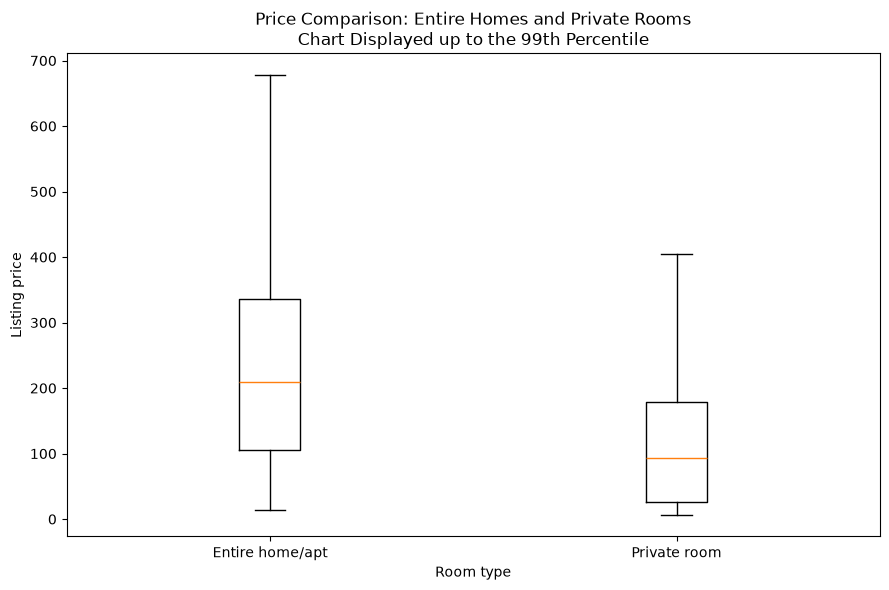

In [23]:
combined_price_limit = np.quantile(
    np.concatenate([
        entire_home_prices,
        private_room_prices
    ]),
    0.99
)

entire_home_chart_values = (
    entire_home_prices[
        entire_home_prices
        <= combined_price_limit
    ]
)

private_room_chart_values = (
    private_room_prices[
        private_room_prices
        <= combined_price_limit
    ]
)

plt.figure(
    figsize=(9, 6)
)

plt.boxplot(
    [
        entire_home_chart_values,
        private_room_chart_values
    ],
    tick_labels=[
        "Entire home/apt",
        "Private room"
    ],
    showfliers=False
)

plt.title(
    "Price Comparison: Entire Homes and Private Rooms\n"
    "Chart Displayed up to the 99th Percentile"
)

plt.xlabel("Room type")
plt.ylabel("Listing price")

plt.tight_layout()

plt.savefig(
    charts_directory
    / "01_entire_home_vs_private_room_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Business interpretation

Use the median difference, confidence interval, p-value, and effect size when
describing the result. A statistically significant difference may still have
limited practical importance if the effect size is small.

The result shows association rather than causation. Entire homes may differ
from private rooms in capacity, location, amenities, and property type.

# Hypothesis 2: Superhosts versus non-superhosts

## Research question

Do superhosts achieve different average listing ratings from non-superhosts?

## Null hypothesis

The distribution of host-level average listing ratings is the same for
superhosts and non-superhosts.

## Alternative hypothesis

The host-level average rating distributions differ.

## Unit of analysis

Ratings are first averaged within each host. This produces one observation
per host and reduces repeated observations from hosts with multiple listings.

In [24]:
host_rating_data = (
    listings[
        [
            "host_id",
            "host_is_superhost",
            "review_scores_rating"
        ]
    ]
    .dropna(
        subset=[
            "host_id",
            "host_is_superhost",
            "review_scores_rating"
        ]
    )
    .copy()
)

host_rating_data[
    "review_scores_rating"
] = pd.to_numeric(
    host_rating_data[
        "review_scores_rating"
    ],
    errors="coerce"
)

host_rating_data = (
    host_rating_data
    .dropna(
        subset=[
            "review_scores_rating"
        ]
    )
)

host_rating_summary = (
    host_rating_data
    .groupby(
        [
            "host_id",
            "host_is_superhost"
        ],
        as_index=False
    )
    .agg(
        average_host_rating=(
            "review_scores_rating",
            "mean"
        ),
        rated_listing_count=(
            "review_scores_rating",
            "count"
        )
    )
)

display(host_rating_summary.head())

print(
    host_rating_summary[
        "host_is_superhost"
    ].value_counts(
        dropna=False
    )
)

,host_id,host_is_superhost,average_host_rating,rated_listing_count
0,228867,False,4.0,1
1,367042,False,4.522,5
2,437092,False,4.65,1
3,696093,False,4.83,1
4,800558,False,4.55,4


host_is_superhost
False    363
True      41
Name: count, dtype: int64


In [25]:
superhost_ratings = numeric_array(
    host_rating_summary.loc[
        host_rating_summary[
            "host_is_superhost"
        ] == True,
        "average_host_rating"
    ]
)

non_superhost_ratings = numeric_array(
    host_rating_summary.loc[
        host_rating_summary[
            "host_is_superhost"
        ] == False,
        "average_host_rating"
    ]
)

h2_result, h2_summary = (
    run_mann_whitney_test(
        hypothesis_name=(
            "H2: Superhost versus "
            "non-superhost ratings"
        ),
        first_group=superhost_ratings,
        second_group=non_superhost_ratings,
        first_group_name="Superhost",
        second_group_name="Non-Superhost"
    )
)

display(h2_summary)

display(
    pd.DataFrame([
        h2_result
    ])
)

,group,observations,mean,median,standard_deviation,first_quartile,third_quartile,skewness
0,Superhost,41,4.8375,4.895,0.1777,4.7614,5.0000,-1.3032
1,Non-Superhost,363,4.5190,4.695,0.6268,4.3875,4.9363,-2.5977


,hypothesis,test,first_group,second_group,first_group_n,second_group_n,first_group_median,second_group_median,median_difference,median_difference_ci_lower,median_difference_ci_upper,u_statistic,p_value,rank_biserial_effect_size,effect_size_magnitude
0,H2: Superhost versus non-superhost ratings,Mann-Whitney U,Superhost,Non-Superhost,41,363,4.895,4.695,0.2,0.083333,0.266667,9937.5,0.000397,0.335416,Moderate


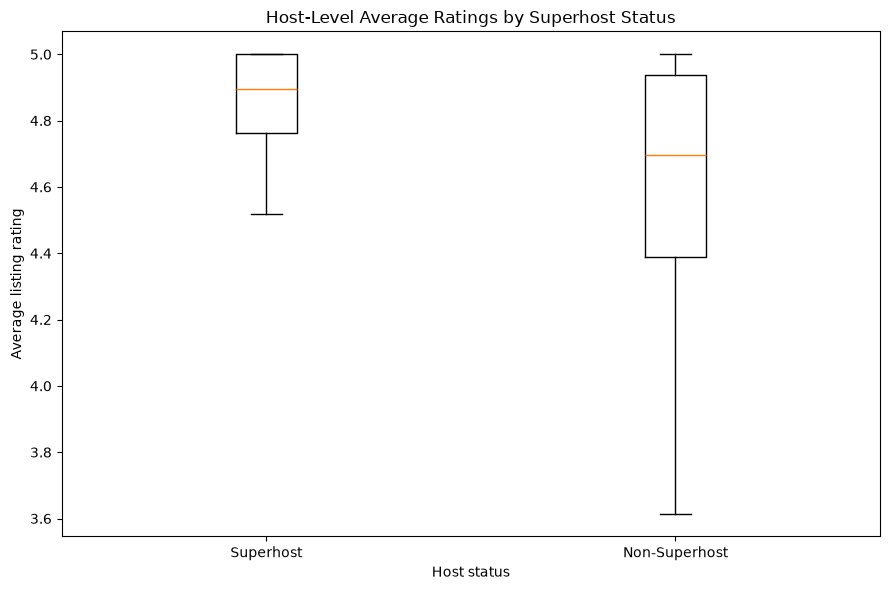

In [26]:
plt.figure(
    figsize=(9, 6)
)

plt.boxplot(
    [
        superhost_ratings,
        non_superhost_ratings
    ],
    tick_labels=[
        "Superhost",
        "Non-Superhost"
    ],
    showfliers=False
)

plt.title(
    "Host-Level Average Ratings by Superhost Status"
)

plt.xlabel("Host status")
plt.ylabel("Average listing rating")

plt.tight_layout()

plt.savefig(
    charts_directory
    / "02_superhost_vs_non_superhost_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Business interpretation

A significant result would show an association between superhost status and
ratings. It would not prove that superhost status causes higher ratings.

Superhost qualification may itself depend partly on service quality and guest
feedback, so the two measures are closely related.

# Hypothesis 3: Review volume and listing price

## Research question

Do listings with more than 10 reviews have different prices from listings
with 10 or fewer reviews?

## Null hypothesis

The price distributions are the same for the two review-volume groups.

## Alternative hypothesis

The price distributions differ.

## Operational definition

The higher-review group contains listings with more than 10 reviews.

The comparison group contains listings with 10 or fewer reviews. This keeps
listings with exactly 10 reviews in the analysis.

In [27]:
review_price_test_data = (
    listings[
        [
            "price",
            "number_of_reviews"
        ]
    ]
    .copy()
)

review_price_test_data[
    "price"
] = pd.to_numeric(
    review_price_test_data[
        "price"
    ],
    errors="coerce"
)

review_price_test_data[
    "number_of_reviews"
] = pd.to_numeric(
    review_price_test_data[
        "number_of_reviews"
    ],
    errors="coerce"
)

review_price_test_data = (
    review_price_test_data
    .dropna(
        subset=[
            "price",
            "number_of_reviews"
        ]
    )
)

more_than_10_review_prices = numeric_array(
    review_price_test_data.loc[
        review_price_test_data[
            "number_of_reviews"
        ] > 10,
        "price"
    ]
)

ten_or_fewer_review_prices = numeric_array(
    review_price_test_data.loc[
        review_price_test_data[
            "number_of_reviews"
        ] <= 10,
        "price"
    ]
)

print(
    "Listings with more than 10 reviews:",
    len(more_than_10_review_prices)
)

print(
    "Listings with 10 or fewer reviews:",
    len(ten_or_fewer_review_prices)
)

Listings with more than 10 reviews: 473
Listings with 10 or fewer reviews: 2269


In [28]:
h3_result, h3_summary = (
    run_mann_whitney_test(
        hypothesis_name=(
            "H3: Price by review-volume group"
        ),
        first_group=more_than_10_review_prices,
        second_group=ten_or_fewer_review_prices,
        first_group_name="More than 10 reviews",
        second_group_name="10 or fewer reviews"
    )
)

display(h3_summary)

display(
    pd.DataFrame([
        h3_result
    ])
)

,group,observations,mean,median,standard_deviation,first_quartile,third_quartile,skewness
0,More than 10 reviews,473,167.9433,125.84,179.2120,54.00,212.0,4.0303
1,10 or fewer reviews,2269,211.8048,130.96,460.9749,43.76,260.4,19.8658


,hypothesis,test,first_group,second_group,first_group_n,second_group_n,first_group_median,second_group_median,median_difference,median_difference_ci_lower,median_difference_ci_upper,u_statistic,p_value,rank_biserial_effect_size,effect_size_magnitude
0,H3: Price by review-volume group,Mann-Whitney U,More than 10 reviews,10 or fewer reviews,473,2269,125.84,130.96,-5.12,-15.47125,14.0,528064.0,0.584974,-0.015941,Negligible


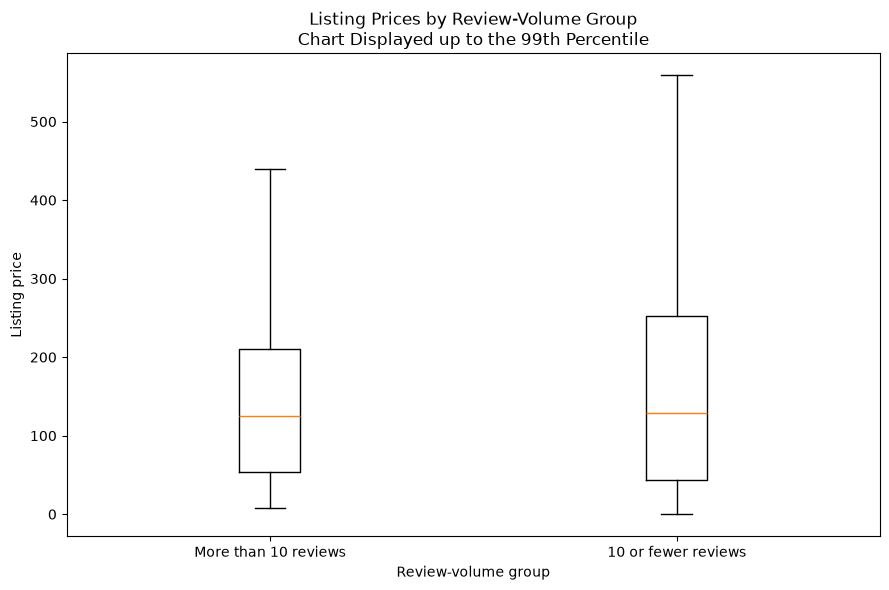

In [29]:
review_group_price_limit = np.quantile(
    np.concatenate([
        more_than_10_review_prices,
        ten_or_fewer_review_prices
    ]),
    0.99
)

high_review_chart_values = (
    more_than_10_review_prices[
        more_than_10_review_prices
        <= review_group_price_limit
    ]
)

lower_review_chart_values = (
    ten_or_fewer_review_prices[
        ten_or_fewer_review_prices
        <= review_group_price_limit
    ]
)

plt.figure(
    figsize=(9, 6)
)

plt.boxplot(
    [
        high_review_chart_values,
        lower_review_chart_values
    ],
    tick_labels=[
        "More than 10 reviews",
        "10 or fewer reviews"
    ],
    showfliers=False
)

plt.title(
    "Listing Prices by Review-Volume Group\n"
    "Chart Displayed up to the 99th Percentile"
)

plt.xlabel("Review-volume group")
plt.ylabel("Listing price")

plt.tight_layout()

plt.savefig(
    charts_directory
    / "03_price_by_review_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Business interpretation

Review count can act as an imperfect indicator of historical guest activity,
but it is also affected by listing age and the percentage of guests who leave
reviews.

A price difference between the groups would not prove that review volume
causes prices to change.

In [30]:
statistical_results = pd.DataFrame([
    h1_result,
    h2_result,
    h3_result
])

display(statistical_results)

,hypothesis,test,first_group,second_group,first_group_n,second_group_n,first_group_median,second_group_median,median_difference,median_difference_ci_lower,median_difference_ci_upper,u_statistic,p_value,rank_biserial_effect_size,effect_size_magnitude
0,H1: Entire-home versus private-room prices,Mann-Whitney U,Entire home/apt,Private room,1092,1509,214.110,93.870,120.24,103.409375,135.330625,1213167.5,3.190809e-94,0.472444,Moderate
1,H2: Superhost versus non-superhost ratings,Mann-Whitney U,Superhost,Non-Superhost,41,363,4.895,4.695,0.20,0.083333,0.266667,9937.5,3.966590e-04,0.335416,Moderate
2,H3: Price by review-volume group,Mann-Whitney U,More than 10 reviews,10 or fewer reviews,473,2269,125.840,130.960,-5.12,-15.471250,14.000000,528064.0,5.849737e-01,-0.015941,Negligible


In [31]:
from statsmodels.stats.multitest import multipletests


(
    reject_null,
    adjusted_p_values,
    _,
    _
) = multipletests(
    statistical_results["p_value"],
    alpha=0.05,
    method="holm"
)

statistical_results[
    "holm_adjusted_p_value"
] = adjusted_p_values

statistical_results[
    "significant_after_holm_correction"
] = reject_null

statistical_results[
    "decision"
] = np.where(
    statistical_results[
        "significant_after_holm_correction"
    ],
    "Reject the null hypothesis",
    "Fail to reject the null hypothesis"
)

display(
    statistical_results[
        [
            "hypothesis",
            "first_group_median",
            "second_group_median",
            "median_difference",
            "median_difference_ci_lower",
            "median_difference_ci_upper",
            "p_value",
            "holm_adjusted_p_value",
            "rank_biserial_effect_size",
            "effect_size_magnitude",
            "decision"
        ]
    ]
)

,hypothesis,first_group_median,second_group_median,median_difference,median_difference_ci_lower,median_difference_ci_upper,p_value,holm_adjusted_p_value,rank_biserial_effect_size,effect_size_magnitude,decision
0,H1: Entire-home versus private-room prices,214.110,93.870,120.24,103.409375,135.330625,3.190809e-94,9.572428e-94,0.472444,Moderate,Reject the null hypothesis
1,H2: Superhost versus non-superhost ratings,4.895,4.695,0.20,0.083333,0.266667,3.966590e-04,7.933180e-04,0.335416,Moderate,Reject the null hypothesis
2,H3: Price by review-volume group,125.840,130.960,-5.12,-15.471250,14.000000,5.849737e-01,5.849737e-01,-0.015941,Negligible,Fail to reject the null hypothesis


In [32]:
statistical_results.to_csv(
    tables_directory
    / "statistical_results.csv",
    index=False
)

h1_summary.to_csv(
    tables_directory
    / "h1_group_summary.csv",
    index=False
)

h2_summary.to_csv(
    tables_directory
    / "h2_group_summary.csv",
    index=False
)

h3_summary.to_csv(
    tables_directory
    / "h3_group_summary.csv",
    index=False
)

host_rating_summary.to_csv(
    tables_directory
    / "host_level_rating_data.csv",
    index=False
)

print(
    "Statistical outputs saved successfully."
)

Statistical outputs saved successfully.


In [33]:
methodology_table = pd.DataFrame([
    {
        "hypothesis": "H1",
        "question": (
            "Entire-home versus "
            "private-room prices"
        ),
        "unit_of_analysis": "Listing",
        "outcome": "Listing price",
        "test": "Mann-Whitney U",
        "reason": (
            "Independent groups with a "
            "skewed numerical outcome"
        ),
        "effect_size": (
            "Rank-biserial correlation"
        ),
        "confidence_interval": (
            "Bootstrap interval for "
            "median difference"
        )
    },
    {
        "hypothesis": "H2",
        "question": (
            "Superhost versus "
            "non-superhost ratings"
        ),
        "unit_of_analysis": "Host",
        "outcome": (
            "Host-level average "
            "listing rating"
        ),
        "test": "Mann-Whitney U",
        "reason": (
            "Independent host groups with "
            "bounded, non-normal ratings"
        ),
        "effect_size": (
            "Rank-biserial correlation"
        ),
        "confidence_interval": (
            "Bootstrap interval for "
            "median difference"
        )
    },
    {
        "hypothesis": "H3",
        "question": (
            "Price by review-volume group"
        ),
        "unit_of_analysis": "Listing",
        "outcome": "Listing price",
        "test": "Mann-Whitney U",
        "reason": (
            "Independent groups with a "
            "skewed numerical outcome"
        ),
        "effect_size": (
            "Rank-biserial correlation"
        ),
        "confidence_interval": (
            "Bootstrap interval for "
            "median difference"
        )
    }
])

display(methodology_table)

methodology_table.to_csv(
    tables_directory
    / "statistical_methodology.csv",
    index=False
)

,hypothesis,question,unit_of_analysis,outcome,test,reason,effect_size,confidence_interval
0,H1,Entire-home versus private-room prices,Listing,Listing price,Mann-Whitney U,Independent groups with a skewed numerical out...,Rank-biserial correlation,Bootstrap interval for median difference
1,H2,Superhost versus non-superhost ratings,Host,Host-level average listing rating,Mann-Whitney U,"Independent host groups with bounded, non-norm...",Rank-biserial correlation,Bootstrap interval for median difference
2,H3,Price by review-volume group,Listing,Listing price,Mann-Whitney U,Independent groups with a skewed numerical out...,Rank-biserial correlation,Bootstrap interval for median difference


In [34]:
print(statistical_results.shape)
display(statistical_results)

(3, 18)


,hypothesis,test,first_group,second_group,first_group_n,second_group_n,first_group_median,second_group_median,median_difference,median_difference_ci_lower,median_difference_ci_upper,u_statistic,p_value,rank_biserial_effect_size,effect_size_magnitude,holm_adjusted_p_value,significant_after_holm_correction,decision
0,H1: Entire-home versus private-room prices,Mann-Whitney U,Entire home/apt,Private room,1092,1509,214.110,93.870,120.24,103.409375,135.330625,1213167.5,3.190809e-94,0.472444,Moderate,9.572428e-94,True,Reject the null hypothesis
1,H2: Superhost versus non-superhost ratings,Mann-Whitney U,Superhost,Non-Superhost,41,363,4.895,4.695,0.20,0.083333,0.266667,9937.5,3.966590e-04,0.335416,Moderate,7.933180e-04,True,Reject the null hypothesis
2,H3: Price by review-volume group,Mann-Whitney U,More than 10 reviews,10 or fewer reviews,473,2269,125.840,130.960,-5.12,-15.471250,14.000000,528064.0,5.849737e-01,-0.015941,Negligible,5.849737e-01,False,Fail to reject the null hypothesis
